/opt/conda/envs/km310env/lib/python3.10/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


Could not import deepdish!
Could not import ray. Parallelized model unavailble.


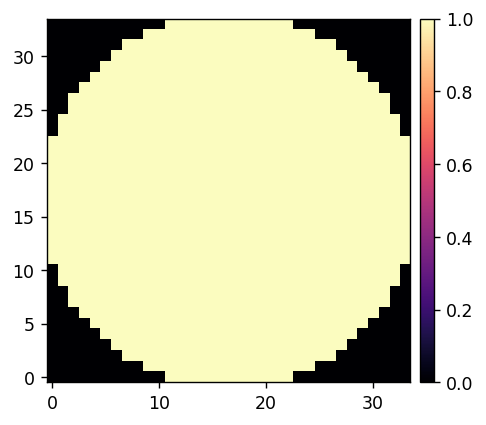

In [1]:
import numpy as np
import astropy.units as u
import threading as th
import time 
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from IPython.display import clear_output
from importlib import reload
import copy
import os
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle

import scoob_llowfsc
from scoob_llowfsc.math_module import xp, xcipy, ensure_np_array
from scoob_llowfsc import utils
from scoob_llowfsc import dm
from scoob_llowfsc import telem
import scoob_llowfsc.scoob_interface as scoobi
from scoob_llowfsc import wfe

wavelength_c = 633e-9

Nact = 34
dm_mask = ensure_np_array(dm.make_mask(Nact))
utils.imshow([dm_mask])

data_path = scoob_llowfsc.path/'exp-data'

In [2]:

# date = 20250409
# date = 20250410
date = today
exp_path = data_path/f'exp-{date}'
wfe_data_path = data_path/f'exp-{today}'/'wfe'
wfe_telem_path = wfe_data_path/'raw-telem'
wfe_unpacked_path = wfe_data_path/'unpacked-telem'

In [28]:
telem.make_dir(exp_path)
telem.make_dir(wfe_data_path)
telem.make_dir(wfe_telem_path)
telem.make_dir(wfe_unpacked_path)

Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250414' already exists.
Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250414/wfe' already exists.
Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250414/wfe/raw-telem' already exists.
Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250414/wfe/unpacked-telem' already exists.


29.0888208681574 nm
0.002


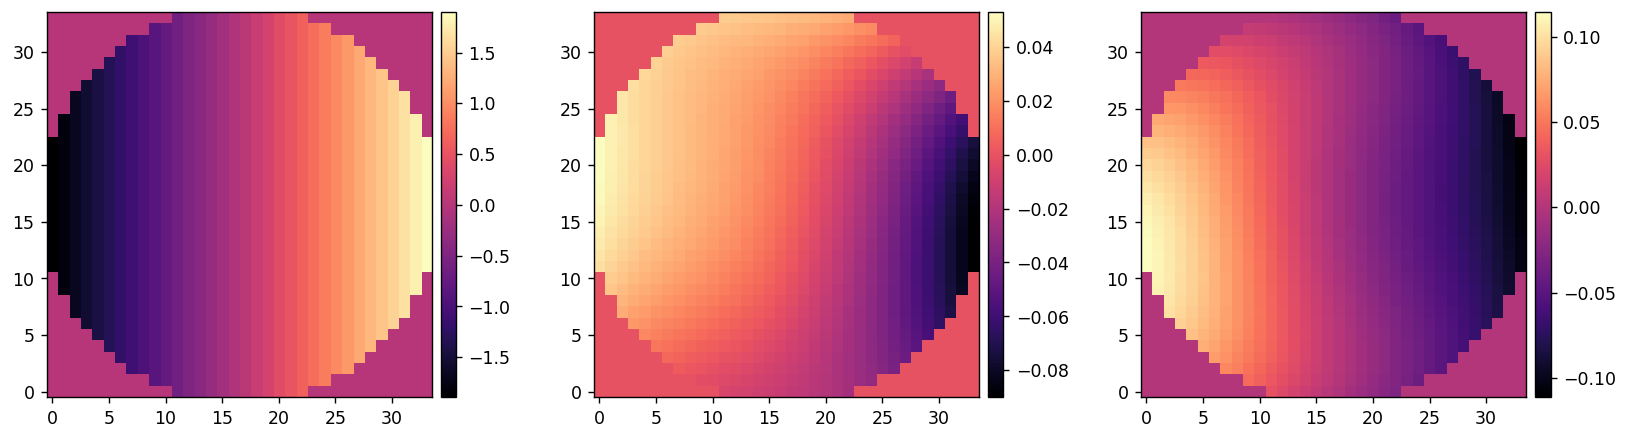

In [8]:
reload(wfe)

total_pupil_diam = 2.4*u.m
dm_beam_diam = 9.1*u.mm
jitter = 10*u.mas 

fmax = 250*u.Hz
tmax = 10*u.s
tmax = 15*u.min
# tmax = 1*u.hour
# tmax = 5*u.hour

mag = (total_pupil_diam / dm_beam_diam).decompose().value
tt_pv_to_rms = 1/4
tt_at_pupil_pv = np.tan(mag*jitter).value * dm_beam_diam
tt_at_pupil_rms = tt_at_pupil_pv * tt_pv_to_rms
print(tt_at_pupil_rms.to(u.nm))

wfe_modes_rms = np.array(2*[tt_at_pupil_rms.to_value(u.um)] + 8*[2.5e-3])
# wfe_modes_rms = np.array(2*[20e-9] + 8*[2.5e-9])
# wfe_modes_rms = np.array(2*[30e-9] + 3*[5e-9] + 5*[2.5e-9])
knee_freqs = np.array([0.1]*2 + [0.01]*8) * u.Hz
slope = 4

N_wfe_modes = len(wfe_modes_rms)
wfe_modes = utils.create_zernike_modes(dm_mask, nmodes=N_wfe_modes, remove_modes=1)

freqs, times = wfe.generate_freqs(Nf=2**22+1, f_max=fmax)

wfe_psds = xp.zeros((N_wfe_modes, len(freqs)))
wfe_time_series = xp.zeros((N_wfe_modes, len(times)))
seeds = 1234 + np.linspace(0, N_wfe_modes-1, N_wfe_modes).astype(int)
for i in range(N_wfe_modes):
    f_knee = knee_freqs[i]
    psd = wfe.kneePSD(freqs, 1, f_knee.to_value(u.Hz), slope)
    wfe_psds[i] = copy.copy(psd)
    coeff = wfe.generate_time_series(psd, fmax, rms=1, seed=seeds[i])
    sign = 1 if xp.random.randn(1)>0 else -1
    wfe_time_series[i] = wfe_modes_rms[i] * sign * xp.array(coeff)

wfe_time_series = wfe_time_series[:, times<tmax.to_value(u.s)]
for i in range(N_wfe_modes):
    wfe_time_series[i] *= wfe_modes_rms[i]/utils.rms(wfe_time_series[i])

times = times[times<tmax.to_value(u.s)]
interval = float(times[1] - times[0])
print(interval)

Nsamps = times.shape[0]
tip = wfe_time_series[0]
tilt = wfe_time_series[1]
defocus = wfe_time_series[2]

wfe_time_series = ensure_np_array(wfe_time_series)
wfe_modes = ensure_np_array(wfe_modes)

lo_wfe_first = np.sum( wfe_time_series[:, 0, None, None] * wfe_modes, axis=0)
lo_wfe_last = np.sum( wfe_time_series[:, -1, None, None] * wfe_modes, axis=0)
utils.imshow([wfe_modes[0], lo_wfe_first, lo_wfe_last])


In [5]:
wfe_data = {
    'times':times,
    'wfe_rms_time_series':wfe_time_series,
    'wfe_modes':wfe_modes,
    'modal_rms':wfe_modes_rms,
    'modal_knee_freqs':knee_freqs,
    'seeds':seeds,
    'fmax':fmax,
}
utils.save_pickle(wfe_data_path/'wfe_data.pkl', wfe_data)

Saved data to:  /home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250414/wfe/wfe_data.pkl


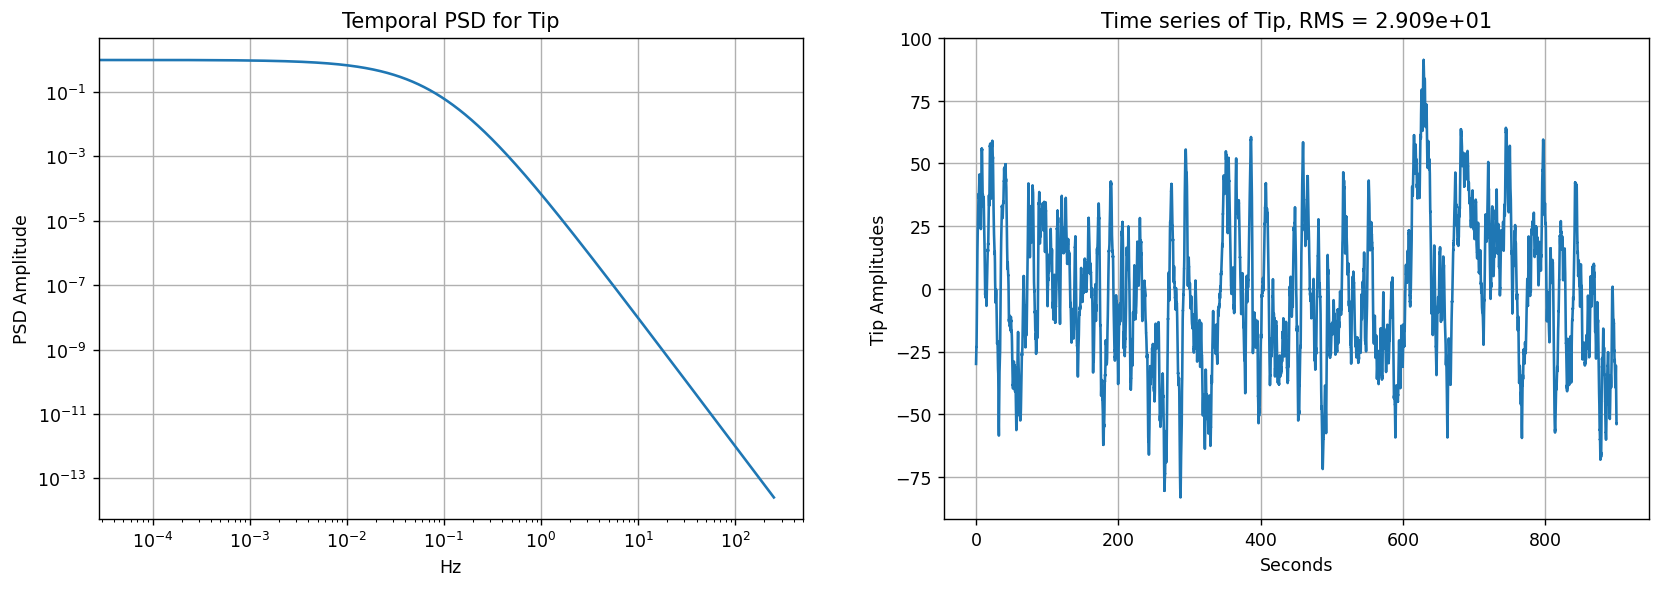

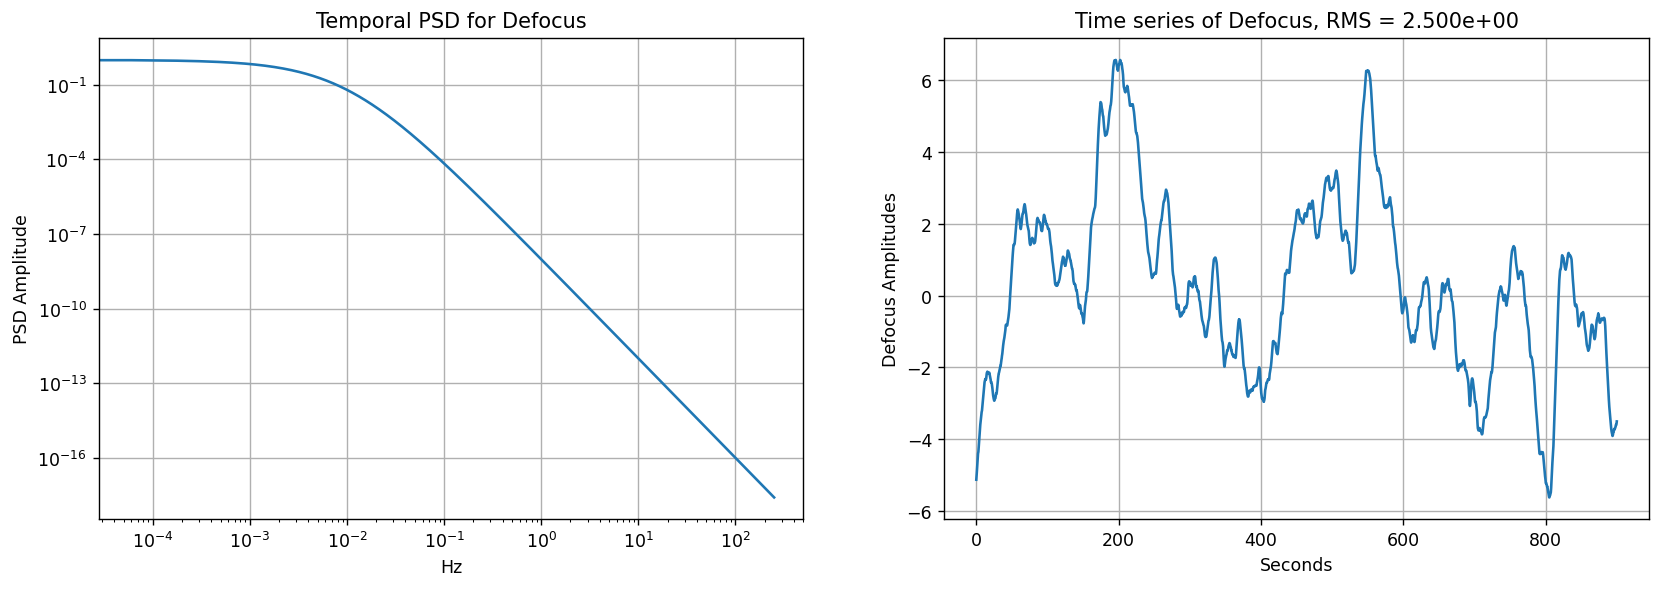

In [9]:
reload(wfe)
i = 0
psd = wfe_psds[i]
coeff = wfe_time_series[i]

wfe.plot_psd_and_time_series(
    freqs, psd,
    times, coeff*1e3,
    psd_name='for Tip',
    coeff_name='Tip',
    psd_xlims=[freqs.min(), 500],
    # coeff_xlims=[0, 3600],
    # coeff_xticks=np.arange(0,3600+1,600),
    figsize=(16,5),
)

i = 8
psd = wfe_psds[i]
coeff = wfe_time_series[i]

wfe.plot_psd_and_time_series(
    freqs, psd,
    times, coeff*1e3,
    psd_name='for Defocus',
    coeff_name='Defocus',
    psd_xlims=[freqs.min(), 500],
    # coeff_xlims=[0, 3600],
    # coeff_xticks=np.arange(0,3600+1,600),
    figsize=(16,5),
)


In [35]:
wfe_modes.shape, wfe_time_series.shape

((10, 34, 34), (10, 1800000))

In [10]:
wfe_cube = np.zeros((wfe_time_series.shape[1], Nact, Nact), )
# wfe_cube = np.zeros((wfe_time_series.shape[1], Nact, Nact), dtype=np.float32)
print(wfe_cube.shape)

for i in range(wfe_time_series.shape[1]):
    wfe_cube[i] = np.sum( wfe_time_series[:, i, None, None] * wfe_modes, axis=0)

(450000, 34, 34)


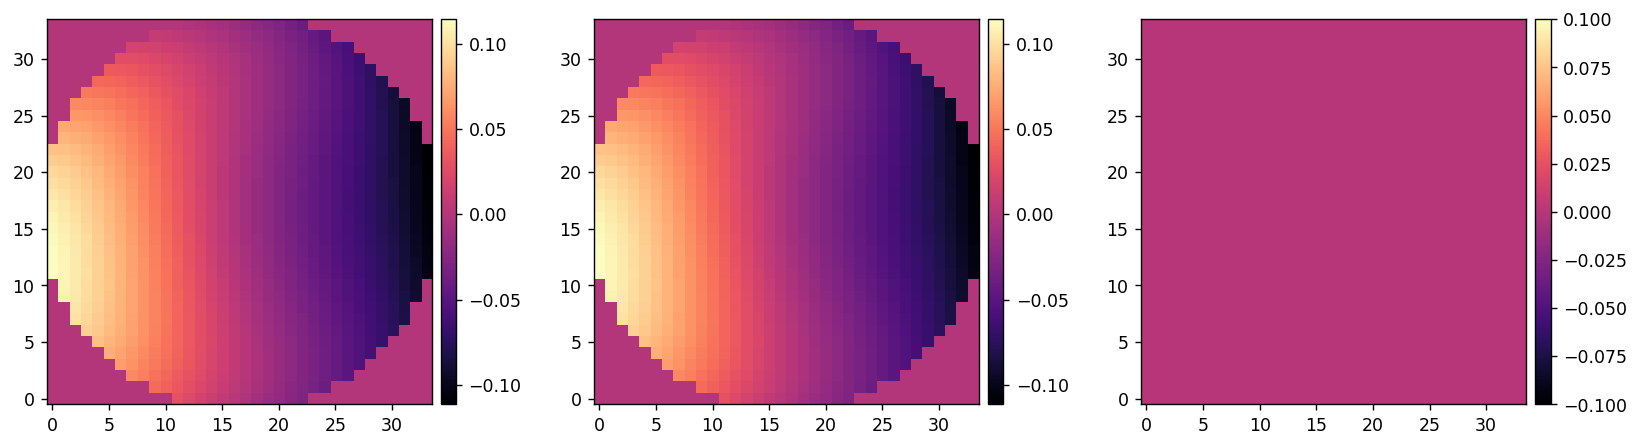

In [11]:
utils.imshow(
    [wfe_cube[-1], np.flip(wfe_cube, axis=0)[1], wfe_cube[-1]-np.flip(wfe_cube, axis=0)[0]]
)

In [13]:
full_cube = np.concatenate([wfe_cube, np.flip(wfe_cube, axis=0)[1:-1]])

In [14]:
utils.save_fits('/opt/MagAOX/calib/dm/kilo/wfe_cube_15min_500Hz_looped_64bit.fits', full_cube)

Saved data to:  /opt/MagAOX/calib/dm/kilo/wfe_cube_15min_500Hz_looped_64bit.fits


In [ ]:
sudo chmod 666 /opt/MagAOX/calib/dm/kilo/wfe_cube*

In [ ]:
sudo chown xsup /opt/MagAOX/calib/dm/kilo/wfe_cube*